# 10 — Cooling Thermal Model Calibration (Offline)

**Purpose:** Offline calibration of HLC, OE, and τ for cooling mode using `cooling_training_data.csv.gz`.
Compares OLS vs scipy optimization, investigates τ explosion (41h vs 4.8h heating),
evaluates HP-ON vs HP-OFF dual-HLC, and tests Open Meteo solar radiation as PV replacement.

**Data:** 47,941 rows × 76 columns (5-min resolution, warm-season cooling periods)

**Key Questions:**
1. Why is cooling HLC ~0.049 while heating HLC ~0.12? (building property should be constant)
2. Why did τ explode to 41h in online learning? Can we constrain it?
3. Is Open Meteo GHI a better solar feature than local PV_Generate for thermal calibration?
4. Does using separate HP-ON vs HP-OFF HLC values improve predictions?

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import optimize, stats
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

# Project root
PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
DATA_PATH = PROJECT_ROOT / "Logs_and_models" / "cooling_training_data.csv.gz"

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH, "exists:", DATA_PATH.exists())

Project root: c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor
Data path: c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\Logs_and_models\cooling_training_data.csv.gz exists: True


## Phase A: Data Loading & Exploration

In [2]:
# Load cooling training data
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Reconstruct hour from sin/cos encoding
df["hour"] = (np.degrees(np.arctan2(df["hour_sin"], df["hour_cos"])) / 15) % 24

# Key derived columns
df["driving_force"] = df["indoor_temp"] - df["AT"]  # T_indoor - T_outdoor
df["cooling_drive"] = df["indoor_temp"] - df["VLT"]  # T_indoor - T_outlet
df["oe_raw"] = np.where(
    df["cooling_drive"].abs() > 0.3,
    df["thermal_power_kw"].abs() / df["cooling_drive"],
    np.nan
)

# Clean outliers (AT has values up to 839°C — clearly sensor errors)
mask_clean = (df["AT"] > -10) & (df["AT"] < 45) & (df["VLT"] > 10) & (df["VLT"] < 45)
print(f"Clean rows: {mask_clean.sum()} of {len(df)} ({100*mask_clean.mean():.1f}%)")
df_clean = df[mask_clean].copy()

# Identify periods
df_clean["is_cooling_active"] = (df_clean["is_hp_active"] == 1) & (df_clean["delta_t"] < -0.5)
df_clean["is_night"] = (df_clean["hour"] < 6) | (df_clean["hour"] > 21)
df_clean["has_pv"] = df_clean["PV_Generate"] > 50

print(f"\nHP ON: {(df_clean['is_hp_active']==1).sum()} ({100*(df_clean['is_hp_active']==1).mean():.1f}%)")
print(f"HP OFF: {(df_clean['is_hp_active']==0).sum()} ({100*(df_clean['is_hp_active']==0).mean():.1f}%)")
print(f"Active cooling (HP ON, ΔT<-0.5): {df_clean['is_cooling_active'].sum()} ({100*df_clean['is_cooling_active'].mean():.1f}%)")
print(f"Night cooling (active + PV<50): {(df_clean['is_cooling_active'] & ~df_clean['has_pv']).sum()}")
df_clean.describe().round(3)

Shape: (47941, 76)
Columns: ['indoor_temp', 'indoor_margin', 'indoor_trend_30m', 'indoor_trend_1h', 'AT', 'at_delta_indoor', 'AT_roh_1h', 'AT_roh_2h', 'AT_roh_3h', 'AT_roh_4h', 'AT_roh_5h', 'AT_roh_6h', 'AT_roh_7h', 'AT_roh_8h', 'AT_roh_9h', 'AT_roh_10h', 'AT_roh_11h', 'AT_roh_12h', 'PV_Generate', 'pv_roll_1h', 'pv_roll_2h', 'pv_forecast_1h', 'pv_forecast_2h', 'pv_forecast_3h', 'pv_forecast_4h', 'pv_forecast_5h', 'pv_forecast_6h', 'pv_forecast_7h', 'pv_forecast_8h', 'pv_forecast_9h', 'pv_forecast_10h', 'pv_forecast_11h', 'pv_forecast_12h', 'thermal_power_kw', 'delta_t', 'outlet_indoor_diff', 'VLT', 'RLT', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'wind_speed', 'living_room_temp', 'fireplace_on', 'tv_on', 'fireplace_lag_30m', 'fireplace_lag_1h', 'fireplace_lag_2h', 'tv_lag_30m', 'tv_lag_1h', 'heat_loss_driving_force', 'indoor_temp_gradient', 'indoor_margin_rate', 'delta_T_indoor_lag1', 'd_inlet_temp_60min', 'is_equilibrium', 'thermal_power_rolling_1h', 'is_overshoot', 'is_hp_active'

,indoor_temp,indoor_margin,indoor_trend_30m,indoor_trend_1h,AT,at_delta_indoor,AT_roh_1h,AT_roh_2h,AT_roh_3h,AT_roh_4h,...,traj_predicted_error,traj_convergence_rate,traj_reaches_target_hours,traj_overshoot_magnitude,traj_equilibrium_gap,label,hour,driving_force,cooling_drive,oe_raw
count,47933.000,47933.000,47933.000,47933.000,47933.000,47933.000,47933.000,47933.000,47933.000,47933.000,...,47933.000,47933.000,47933.000,47933.000,47933.000,47933.000,47933.000,47933.000,47933.000,39174.000
mean,23.015,-0.015,-0.000,-0.000,17.260,-5.755,17.296,17.296,17.300,17.298,...,-0.513,0.011,4.731,0.523,-0.638,0.656,12.469,5.755,-0.092,-0.053
std,0.438,0.438,0.064,0.100,5.343,5.268,7.526,7.531,7.539,7.550,...,1.360,0.029,3.404,0.866,1.696,0.475,6.282,5.268,2.462,0.415
min,20.520,-1.330,-1.200,-1.450,10.020,-13.802,9.103,8.548,8.195,8.408,...,-4.273,-0.192,0.000,0.000,-5.296,0.000,0.000,-10.730,-14.760,-4.978
25%,22.756,-0.320,-0.010,-0.028,12.900,-9.990,12.930,12.920,12.943,12.957,...,-1.195,-0.002,1.013,0.000,-1.459,0.000,7.833,2.350,-1.300,-0.342
50%,23.020,-0.020,0.000,0.008,16.040,-6.890,16.088,16.101,16.115,16.113,...,-0.581,0.011,6.871,0.220,-0.724,1.000,12.750,6.890,-0.230,-0.021
75%,23.320,0.244,0.020,0.040,20.700,-2.350,20.716,20.714,20.714,20.724,...,0.162,0.025,8.000,0.620,0.170,1.000,17.333,9.990,0.850,0.189
max,24.330,2.480,0.848,0.858,33.900,10.730,839.396,838.855,838.981,839.977,...,10.063,0.094,8.000,12.334,12.334,1.000,23.917,13.802,5.970,4.048


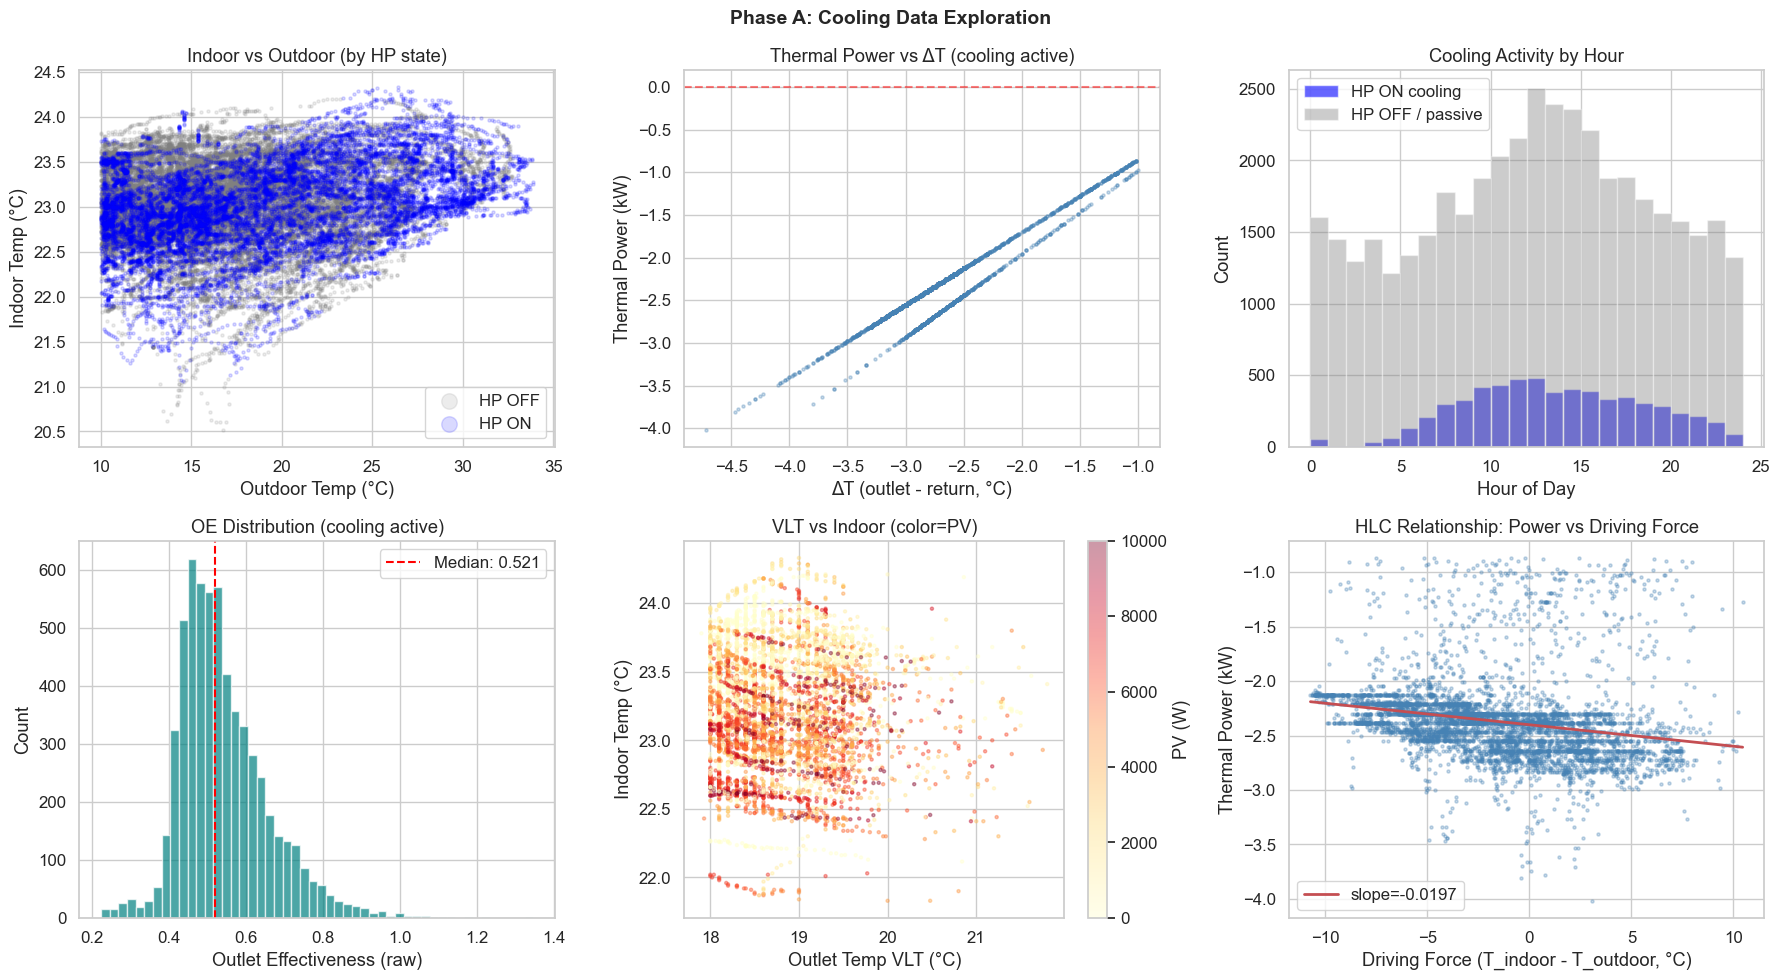

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1) Indoor vs Outdoor colored by HP state
ax = axes[0, 0]
for label, color, marker in [(0, "gray", "."), (1, "blue", ".")]:
    mask = df_clean["is_hp_active"] == label
    ax.scatter(df_clean.loc[mask, "AT"], df_clean.loc[mask, "indoor_temp"],
               c=color, alpha=0.15, s=5, label=f"HP {'ON' if label else 'OFF'}")
ax.set_xlabel("Outdoor Temp (°C)")
ax.set_ylabel("Indoor Temp (°C)")
ax.set_title("Indoor vs Outdoor (by HP state)")
ax.legend(markerscale=5)

# 2) Thermal power vs delta_t
ax = axes[0, 1]
cool = df_clean[df_clean["is_cooling_active"]]
ax.scatter(cool["delta_t"], cool["thermal_power_kw"], c="steelblue", alpha=0.3, s=5)
ax.set_xlabel("ΔT (outlet - return, °C)")
ax.set_ylabel("Thermal Power (kW)")
ax.set_title("Thermal Power vs ΔT (cooling active)")
ax.axhline(0, color="red", ls="--", alpha=0.5)

# 3) Hour distribution by HP state
ax = axes[0, 2]
bins = np.arange(0, 25, 1)
ax.hist(df_clean.loc[df_clean["is_cooling_active"], "hour"], bins=bins, alpha=0.6, label="HP ON cooling", color="blue")
ax.hist(df_clean.loc[~df_clean["is_cooling_active"], "hour"], bins=bins, alpha=0.4, label="HP OFF / passive", color="gray")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Count")
ax.set_title("Cooling Activity by Hour")
ax.legend()

# 4) OE raw distribution
ax = axes[1, 0]
oe_valid = df_clean.loc[df_clean["is_cooling_active"], "oe_raw"].dropna()
oe_clipped = oe_valid.clip(0, 3)
ax.hist(oe_clipped, bins=50, color="teal", alpha=0.7)
ax.axvline(oe_clipped.median(), color="red", ls="--", label=f"Median: {oe_clipped.median():.3f}")
ax.set_xlabel("Outlet Effectiveness (raw)")
ax.set_ylabel("Count")
ax.set_title("OE Distribution (cooling active)")
ax.legend()

# 5) VLT vs Indoor (cooling active)
ax = axes[1, 1]
ax.scatter(cool["VLT"], cool["indoor_temp"], c=cool["PV_Generate"], cmap="YlOrRd",
           alpha=0.4, s=5, vmin=0, vmax=10000)
ax.set_xlabel("Outlet Temp VLT (°C)")
ax.set_ylabel("Indoor Temp (°C)")
ax.set_title("VLT vs Indoor (color=PV)")
plt.colorbar(ax.collections[0], ax=ax, label="PV (W)")

# 6) Driving force vs thermal power
ax = axes[1, 2]
ax.scatter(cool["driving_force"], cool["thermal_power_kw"], c="steelblue", alpha=0.3, s=5)
ax.set_xlabel("Driving Force (T_indoor - T_outdoor, °C)")
ax.set_ylabel("Thermal Power (kW)")
ax.set_title("HLC Relationship: Power vs Driving Force")
# Quick OLS line
from numpy.polynomial.polynomial import polyfit
mask_valid = cool["driving_force"].notna() & cool["thermal_power_kw"].notna()
if mask_valid.sum() > 10:
    b = np.polyfit(cool.loc[mask_valid, "driving_force"], cool.loc[mask_valid, "thermal_power_kw"], 1)
    x_fit = np.linspace(cool["driving_force"].min(), cool["driving_force"].max(), 100)
    ax.plot(x_fit, np.polyval(b, x_fit), "r-", lw=2, label=f"slope={b[0]:.4f}")
    ax.legend()

plt.suptitle("Phase A: Cooling Data Exploration", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Phase B: HLC Calibration

The Heat Loss Coefficient (HLC) should be a building property: `Q_thermal = HLC × (T_indoor − T_outdoor)`.
- **Heating mode** online learning converged to HLC ≈ 0.12
- **Cooling mode** online learning converged to HLC ≈ 0.049 (nearly 3× lower!)

**Hypothesis**: The difference comes from:
1. HP mostly off at night in cooling → insufficient forced-convection data
2. Daytime solar gains not properly accounted for → model absorbs solar into a lower HLC
3. The online learner sees HP-OFF periods where indoor barely changes → interprets as low heat exchange

In [4]:
# Replicate calibrate_hlc() from src/hlc_learner.py
# Forced-through-origin OLS: thermal_power = HLC × driving_force

# Filter for stable HP-ON cooling periods
hlc_data = df_clean[
    (df_clean["is_cooling_active"]) &       # HP ON, delta_t < -0.5
    (df_clean["thermal_power_kw"].abs() > 0.5) &  # Meaningful thermal output
    (df_clean["driving_force"].abs() > 1.0)  # Meaningful temperature difference
].copy()

print(f"HLC calibration data: {len(hlc_data)} rows")

# Method 1: All cooling-active periods
X_all = hlc_data["driving_force"].values.reshape(-1, 1)
y_all = hlc_data["thermal_power_kw"].values

# Forced-through-origin OLS: y = b*x → b = Σ(x*y) / Σ(x²)
hlc_ols_all = np.sum(X_all.ravel() * y_all) / np.sum(X_all.ravel() ** 2)

# Method 2: Night-only (PV < 50W) — cleanest signal
night_data = hlc_data[~hlc_data["has_pv"]]
if len(night_data) > 20:
    X_night = night_data["driving_force"].values
    y_night = night_data["thermal_power_kw"].values
    hlc_ols_night = np.sum(X_night * y_night) / np.sum(X_night ** 2)
else:
    hlc_ols_night = np.nan

# Method 3: Daytime (PV > 50W)
day_data = hlc_data[hlc_data["has_pv"]]
if len(day_data) > 20:
    X_day = day_data["driving_force"].values
    y_day = day_data["thermal_power_kw"].values
    hlc_ols_day = np.sum(X_day * y_day) / np.sum(X_day ** 2)
else:
    hlc_ols_day = np.nan

# Method 4: HP-OFF periods (passive heat exchange)
passive_data = df_clean[
    (df_clean["is_hp_active"] == 0) &
    (df_clean["driving_force"].abs() > 2.0) &
    (df_clean["indoor_temp_gradient"].abs() > 0.01)  # Some measurable change
].copy()
# For HP-OFF: use indoor_temp_gradient as proxy for thermal power
# dT/dt ≈ -(HLC/C) × driving_force → HLC ∝ gradient / driving_force
if len(passive_data) > 50:
    hlc_passive_raw = passive_data["indoor_temp_gradient"] / passive_data["driving_force"]
    hlc_ols_passive = hlc_passive_raw.median()
else:
    hlc_ols_passive = np.nan

print(f"\n{'Method':<25} {'HLC':>8} {'N rows':>8}")
print("-" * 45)
print(f"{'OLS All cooling-active':<25} {hlc_ols_all:>8.4f} {len(hlc_data):>8}")
print(f"{'OLS Night-only (PV<50)':<25} {hlc_ols_night:>8.4f} {len(night_data):>8}")
print(f"{'OLS Day-only (PV>50)':<25} {hlc_ols_day:>8.4f} {len(day_data):>8}")
print(f"{'Passive (HP-OFF median)':<25} {hlc_ols_passive:>8.4f} {len(passive_data):>8}")
print(f"{'Online-learned cooling':<25} {'0.0487':>8}")
print(f"{'Online-learned heating':<25} {'0.1206':>8}")

HLC calibration data: 5032 rows

Method                         HLC   N rows
---------------------------------------------
OLS All cooling-active      0.1895     5032
OLS Night-only (PV<50)     -0.4176      912
OLS Day-only (PV>50)        0.2947     4120
Passive (HP-OFF median)    -0.0014    20828
Online-learned cooling      0.0487
Online-learned heating      0.1206


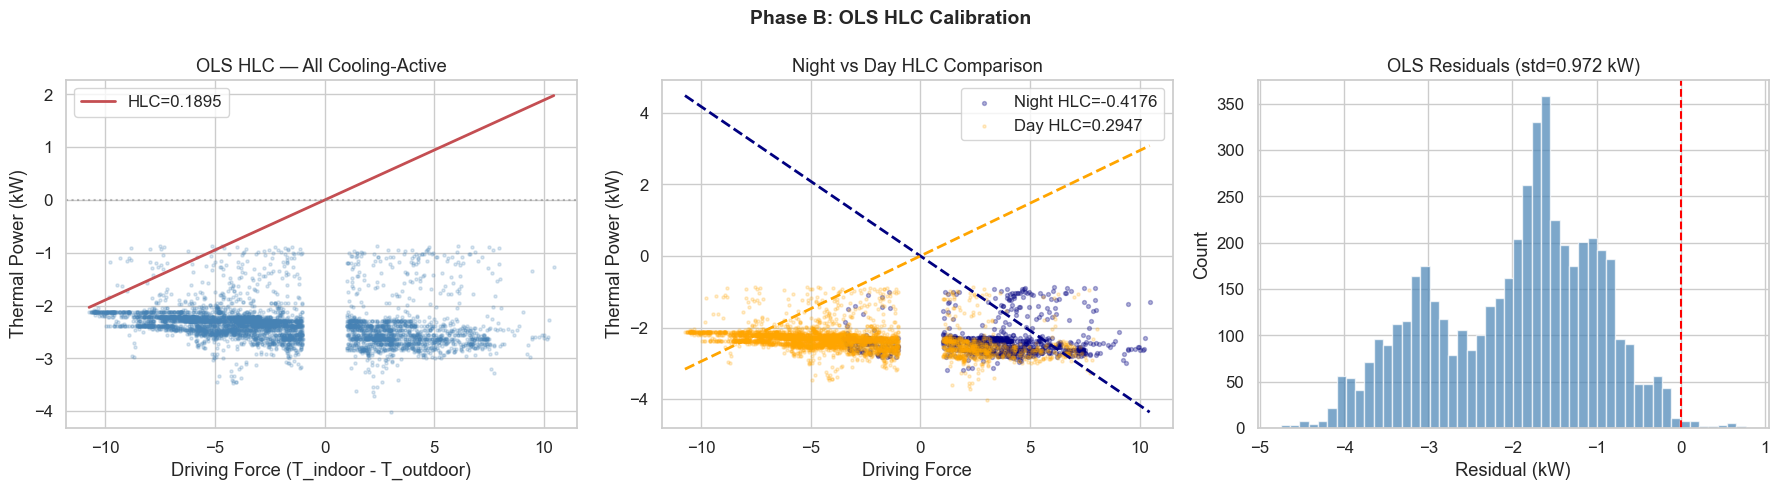

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: All data with OLS fit
ax = axes[0]
ax.scatter(hlc_data["driving_force"], hlc_data["thermal_power_kw"], alpha=0.2, s=5, c="steelblue")
x_range = np.linspace(hlc_data["driving_force"].min(), hlc_data["driving_force"].max(), 100)
ax.plot(x_range, hlc_ols_all * x_range, "r-", lw=2, label=f"HLC={hlc_ols_all:.4f}")
ax.set_xlabel("Driving Force (T_indoor - T_outdoor)")
ax.set_ylabel("Thermal Power (kW)")
ax.set_title("OLS HLC — All Cooling-Active")
ax.legend()
ax.axhline(0, color="gray", ls=":", alpha=0.5)

# Plot 2: Night vs Day comparison
ax = axes[1]
if len(night_data) > 0:
    ax.scatter(night_data["driving_force"], night_data["thermal_power_kw"],
               alpha=0.3, s=8, c="navy", label=f"Night HLC={hlc_ols_night:.4f}")
    ax.plot(x_range, hlc_ols_night * x_range, "navy", lw=2, ls="--")
if len(day_data) > 0:
    ax.scatter(day_data["driving_force"], day_data["thermal_power_kw"],
               alpha=0.2, s=5, c="orange", label=f"Day HLC={hlc_ols_day:.4f}")
    ax.plot(x_range, hlc_ols_day * x_range, "orange", lw=2, ls="--")
ax.set_xlabel("Driving Force")
ax.set_ylabel("Thermal Power (kW)")
ax.set_title("Night vs Day HLC Comparison")
ax.legend()

# Plot 3: Residuals
ax = axes[2]
residuals = hlc_data["thermal_power_kw"] - hlc_ols_all * hlc_data["driving_force"]
ax.hist(residuals, bins=50, alpha=0.7, color="steelblue")
ax.axvline(0, color="red", ls="--")
ax.set_xlabel("Residual (kW)")
ax.set_ylabel("Count")
ax.set_title(f"OLS Residuals (std={residuals.std():.3f} kW)")

plt.suptitle("Phase B: OLS HLC Calibration", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Scipy Joint Optimization (HLC + OE + τ)

Instead of calibrating each parameter separately, optimize all three simultaneously
by minimizing the error between predicted and actual indoor temperature trajectories.

In [6]:
def predict_equilibrium(T_outlet, T_outdoor, HLC, OE, pv_watts=0, pv_weight=0.0001):
    """Predict equilibrium indoor temperature.
    T_eq = (OE * T_outlet + HLC * T_outdoor + Q_ext) / (OE + HLC)
    pv_weight converts W to effective temperature contribution (~0.1 C per kW)
    """
    Q_ext = pv_watts * pv_weight
    return (OE * T_outlet + HLC * T_outdoor + Q_ext) / (OE + HLC)

def simulate_trajectory(params, data, dt_hours=5/60):
    """Simulate indoor temperature trajectory given parameters.
    Returns predicted indoor temps for each row.
    """
    HLC, OE, tau = params
    if tau <= 0 or HLC <= 0 or OE <= 0:
        return np.full(len(data), np.nan)
    
    predicted = np.zeros(len(data))
    predicted[0] = data["indoor_temp"].iloc[0]
    
    for i in range(1, len(data)):
        T_eq = predict_equilibrium(
            data["VLT"].iloc[i], data["AT"].iloc[i], HLC, OE,
            data["PV_Generate"].iloc[i]
        )
        approach = 1 - np.exp(-dt_hours / tau)
        predicted[i] = predicted[i-1] + (T_eq - predicted[i-1]) * approach
    
    return predicted

def cost_function(params, data):
    """Mean squared error between predicted and actual indoor temp."""
    predicted = simulate_trajectory(params, data)
    if np.any(np.isnan(predicted)):
        return 1e6
    return np.mean((predicted - data["indoor_temp"].values) ** 2)

# Physical bounds: HLC [0.02, 0.5], OE [0.1, 1.0], tau [1.5, 8.0]
BOUNDS = [(0.02, 0.5), (0.1, 1.0), (1.5, 8.0)]

# Find contiguous cooling segments (at least 2 hours = 24 rows)
cooling_mask = df_clean["is_cooling_active"].values
segments = []
start = None
for i in range(len(cooling_mask)):
    if cooling_mask[i] and start is None:
        start = i
    elif not cooling_mask[i] and start is not None:
        if i - start >= 24:
            segments.append((start, i))
        start = None
if start is not None and len(cooling_mask) - start >= 24:
    segments.append((start, len(cooling_mask)))

print(f"Found {len(segments)} contiguous cooling segments (>=2h each)")
total_rows = sum(e - s for s, e in segments)
print(f"Total rows for calibration: {total_rows}")

seg_data_list = [df_clean.iloc[s:e].reset_index(drop=True) for s, e in segments]
max_rows = 5000
cal_data = pd.concat(seg_data_list, ignore_index=True).head(max_rows)
print(f"Using {len(cal_data)} rows for scipy optimization")

# 1) Differential evolution (global optimizer, respects bounds)
print("\n--- Differential Evolution ---")
de_result = optimize.differential_evolution(
    cost_function, BOUNDS, args=(cal_data,),
    maxiter=500, seed=42, tol=1e-6, workers=1
)
print(f"DE: HLC={de_result.x[0]:.4f}, OE={de_result.x[1]:.4f}, tau={de_result.x[2]:.2f}h, "
      f"MSE={de_result.fun:.6f}, success={de_result.success}")

# 2) Multi-start L-BFGS-B (local optimizer with bounds)
print("\n--- Multi-start L-BFGS-B ---")
initial_guesses = [
    [0.12, 0.85, 4.5],
    [0.05, 0.72, 4.3],
    [0.08, 0.60, 6.0],
    [0.10, 0.50, 3.5],
]

lb_results = []
for i, x0 in enumerate(initial_guesses):
    res = optimize.minimize(
        cost_function, x0, args=(cal_data,),
        method="L-BFGS-B", bounds=BOUNDS,
        options={"maxiter": 2000}
    )
    lb_results.append(res)
    print(f"Init {i}: HLC={res.x[0]:.4f}, OE={res.x[1]:.4f}, tau={res.x[2]:.2f}h, "
          f"MSE={res.fun:.6f}")

best_lb = min(lb_results, key=lambda r: r.fun)

# Pick overall best
all_results = [de_result] + lb_results
best = min(all_results, key=lambda r: r.fun)
hlc_scipy, oe_scipy, tau_scipy = best.x

print(f"\n{'='*50}")
print(f"BEST: HLC={hlc_scipy:.4f}, OE={oe_scipy:.4f}, tau={tau_scipy:.2f}h")
print(f"MSE={best.fun:.6f}, RMSE={np.sqrt(best.fun):.4f} C")
print(f"{'='*50}")

# Check if hitting bounds
for name, val, (lo, hi) in zip(["HLC", "OE", "tau"], best.x, BOUNDS):
    if abs(val - lo) < 0.001 or abs(val - hi) < 0.001:
        print(f"WARNING: {name}={val:.4f} is at bound [{lo}, {hi}]")

Found 96 contiguous cooling segments (>=2h each)
Total rows for calibration: 5715
Using 5000 rows for scipy optimization

--- Differential Evolution ---
DE: HLC=0.1804, OE=0.1861, tau=8.00h, MSE=1.975718, success=True

--- Multi-start L-BFGS-B ---
Init 0: HLC=0.1995, OE=0.2075, tau=8.00h, MSE=1.987972
Init 1: HLC=0.1804, OE=0.1861, tau=8.00h, MSE=1.975718
Init 2: HLC=0.1804, OE=0.1861, tau=8.00h, MSE=1.975718
Init 3: HLC=0.1804, OE=0.1861, tau=8.00h, MSE=1.975718

BEST: HLC=0.1804, OE=0.1861, tau=8.00h
MSE=1.975718, RMSE=1.4056 C


### HP-ON vs HP-OFF Dual-HLC Calibration

**Hypothesis**: The building has one true HLC, but the *effective* heat exchange differs
when the HP is actively circulating water (forced convection through floor) vs passive (natural convection only).
Test if using separate HLC values for each state improves predictions.

In [7]:
def cost_dual_hlc(params, data):
    """Cost function with separate HLC for HP-ON and HP-OFF."""
    HLC_on, HLC_off, OE, tau = params
    
    predicted = np.zeros(len(data))
    predicted[0] = data["indoor_temp"].iloc[0]
    hp_active = data["is_hp_active"].values
    dt_h = 5 / 60
    
    for i in range(1, len(data)):
        hlc_i = HLC_on if hp_active[i] == 1 else HLC_off
        T_eq = predict_equilibrium(
            data["VLT"].iloc[i], data["AT"].iloc[i], hlc_i, OE,
            data["PV_Generate"].iloc[i]
        )
        approach = 1 - np.exp(-dt_h / tau)
        predicted[i] = predicted[i-1] + (T_eq - predicted[i-1]) * approach
    
    if np.any(np.isnan(predicted)):
        return 1e6
    return np.mean((predicted - data["indoor_temp"].values) ** 2)

# Physical bounds for dual-HLC: HLC_on, HLC_off, OE, tau
DUAL_BOUNDS = [(0.02, 0.5), (0.005, 0.3), (0.1, 1.0), (1.5, 8.0)]

# Use a mixed-mode dataset (includes both HP-ON and HP-OFF)
mixed_data = df_clean.head(max_rows).copy()
print(f"Mixed data: {len(mixed_data)} rows, HP-ON: {mixed_data['is_hp_active'].sum()}, HP-OFF: {(~mixed_data['is_hp_active'].astype(bool)).sum()}")

# Differential evolution for dual-HLC
print("\n--- Dual-HLC Differential Evolution ---")
de_dual = optimize.differential_evolution(
    cost_dual_hlc, DUAL_BOUNDS, args=(mixed_data,),
    maxiter=500, seed=42, tol=1e-6, workers=1
)
hlc_on, hlc_off, oe_dual, tau_dual = de_dual.x
print(f"DE: HLC_on={hlc_on:.4f}, HLC_off={hlc_off:.4f}, OE={oe_dual:.4f}, tau={tau_dual:.2f}h, MSE={de_dual.fun:.6f}")

# Also try L-BFGS-B with multiple starts
print("\n--- Dual-HLC L-BFGS-B ---")
dual_guesses = [
    [0.12, 0.04, 0.85, 4.5],
    [0.10, 0.06, 0.72, 5.0],
    [0.08, 0.02, 0.60, 6.0],
]

dual_results = [de_dual]
for i, x0 in enumerate(dual_guesses):
    res = optimize.minimize(
        cost_dual_hlc, x0, args=(mixed_data,),
        method="L-BFGS-B", bounds=DUAL_BOUNDS,
        options={"maxiter": 3000}
    )
    dual_results.append(res)
    print(f"Init {i}: HLC_on={res.x[0]:.4f}, HLC_off={res.x[1]:.4f}, "
          f"OE={res.x[2]:.4f}, tau={res.x[3]:.2f}h, MSE={res.fun:.6f}")

best_dual = min(dual_results, key=lambda r: r.fun)
hlc_on, hlc_off, oe_dual, tau_dual = best_dual.x
print(f"\n*** BEST DUAL: HLC_on={hlc_on:.4f}, HLC_off={hlc_off:.4f}, OE={oe_dual:.4f}, tau={tau_dual:.2f}h ***")

# Compare single vs dual HLC (both MSE on same mixed data)
single_mse = cost_function([hlc_scipy, oe_scipy, tau_scipy], mixed_data)
dual_mse = best_dual.fun
improvement = (single_mse - dual_mse) / single_mse * 100

print(f"\n{'Model':<25} {'MSE':>10} {'RMSE':>8} {'HLC':>12} {'OE':>8} {'tau':>6}")
print("-" * 75)
print(f"{'Single HLC':<25} {single_mse:>10.4f} {np.sqrt(single_mse):>8.4f} {hlc_scipy:>12.4f} {oe_scipy:>8.4f} {tau_scipy:>6.2f}")
print(f"{'Dual HLC (ON/OFF)':<25} {dual_mse:>10.4f} {np.sqrt(dual_mse):>8.4f} {hlc_on:>6.4f}/{hlc_off:<5.4f} {oe_dual:>8.4f} {tau_dual:>6.2f}")
print(f"\nImprovement: {improvement:.1f}%")

# Check bounds
for name, val, (lo, hi) in zip(["HLC_on", "HLC_off", "OE", "tau"], best_dual.x, DUAL_BOUNDS):
    if abs(val - lo) < 0.001 or abs(val - hi) < 0.001:
        print(f"WARNING: {name}={val:.4f} is at bound [{lo}, {hi}]")

Mixed data: 5000 rows, HP-ON: 2212.0, HP-OFF: 2788

--- Dual-HLC Differential Evolution ---
DE: HLC_on=0.1464, HLC_off=0.0155, OE=0.2088, tau=8.00h, MSE=0.499972

--- Dual-HLC L-BFGS-B ---
Init 0: HLC_on=0.1464, HLC_off=0.0155, OE=0.2088, tau=8.00h, MSE=0.499972
Init 1: HLC_on=0.1464, HLC_off=0.0155, OE=0.2088, tau=8.00h, MSE=0.499972
Init 2: HLC_on=0.1464, HLC_off=0.0155, OE=0.2088, tau=8.00h, MSE=0.499972

*** BEST DUAL: HLC_on=0.1464, HLC_off=0.0155, OE=0.2088, tau=8.00h ***

Model                            MSE     RMSE          HLC       OE    tau
---------------------------------------------------------------------------
Single HLC                    3.5117   1.8740       0.1804   0.1861   8.00
Dual HLC (ON/OFF)             0.5000   0.7071 0.1464/0.0155   0.2088   8.00

Improvement: 85.8%


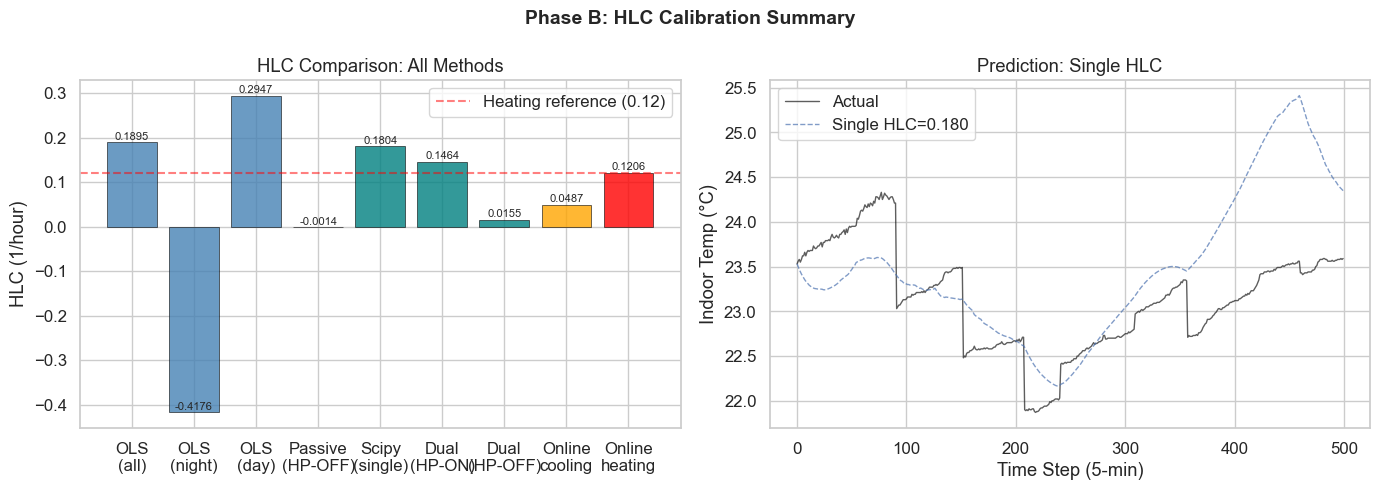

In [8]:
# Summary comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of all HLC estimates
methods = ["OLS\n(all)", "OLS\n(night)", "OLS\n(day)", "Passive\n(HP-OFF)",
           "Scipy\n(single)", "Dual\n(HP-ON)", "Dual\n(HP-OFF)",
           "Online\ncooling", "Online\nheating"]
values = [hlc_ols_all, hlc_ols_night, hlc_ols_day, hlc_ols_passive,
          hlc_scipy, hlc_on, hlc_off, 0.0487, 0.1206]
colors = ["steelblue"]*4 + ["teal"]*3 + ["orange", "red"]

ax = axes[0]
bars = ax.bar(methods, values, color=colors, alpha=0.8, edgecolor="black", linewidth=0.5)
ax.set_ylabel("HLC (1/hour)")
ax.set_title("HLC Comparison: All Methods")
ax.axhline(0.12, color="red", ls="--", alpha=0.5, label="Heating reference (0.12)")
ax.legend()
for bar, val in zip(bars, values):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)

# Prediction comparison: single vs dual HLC
ax = axes[1]
pred_single = simulate_trajectory([hlc_scipy, oe_scipy, tau_scipy], cal_data)
pred_dual_on = simulate_trajectory([hlc_on, oe_dual, tau_dual],
    cal_data[cal_data["is_hp_active"]==1].head(500).reset_index(drop=True)) if (cal_data["is_hp_active"]==1).sum() > 100 else None

actual = cal_data["indoor_temp"].values
ax.plot(actual[:500], "k-", label="Actual", alpha=0.7, lw=1)
ax.plot(pred_single[:500], "b--", label=f"Single HLC={hlc_scipy:.3f}", alpha=0.7, lw=1)
ax.set_xlabel("Time Step (5-min)")
ax.set_ylabel("Indoor Temp (°C)")
ax.set_title("Prediction: Single HLC")
ax.legend()

plt.suptitle("Phase B: HLC Calibration Summary", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Phase C: Outlet Effectiveness (OE) Calibration

OE measures heat transfer efficiency from underfloor heating water to room air.
- **Heating mode**: OE ≈ 0.83–0.95 (forced convection, warm water → cool room)
- **Cooling mode**: Should be similar (same floor, same pipes, reverse direction)
  but natural convection differences may apply.

**Strategy**: Use early morning / late evening HP-ON periods where PV ≈ 0
to isolate the OE calculation from solar confounding.

OE from scipy HLC (0.1804): median=0.1676, mean=0.2050, std=0.1155, n=1025
OE from OLS HLC (0.1895): median=0.1697, mean=0.2102, std=0.1208, n=1073
OE from heating HLC (0.1206): median=0.1584, mean=0.1756, std=0.0803, n=603

Night-only OE (scipy HLC): median=0.1719, n=600

Scipy-optimized OE: 0.1861
Dual-HLC OE: 0.2088
Online-learned (heating): 0.826


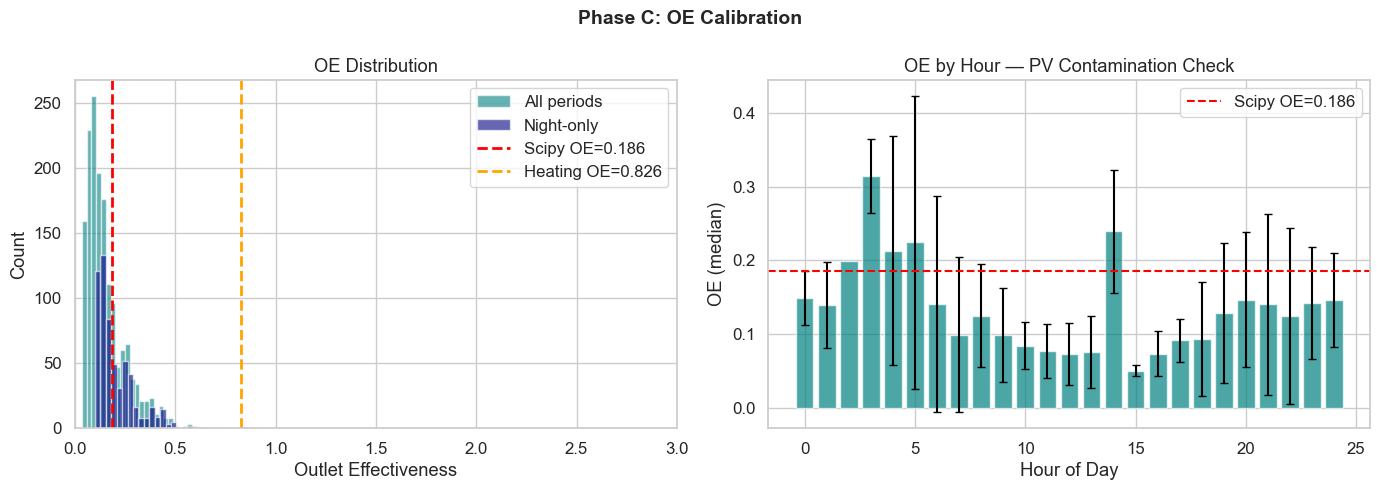

In [9]:
# Method 1: Weighted median (replicating _calibrate_oe_cooling)
oe_data = df_clean[
    (df_clean["is_cooling_active"]) &
    (df_clean["cooling_drive"].abs() > 0.2) &  # Meaningful cooling drive
    (df_clean["driving_force"].abs() > 1.0)
].copy()

# OE = HLC × driving_force / cooling_drive (from equilibrium equation rearranged)
# At equilibrium: OE × (T_indoor - T_outlet) = HLC × (T_indoor - T_outdoor) + Q_ext
# → OE = (HLC × driving_force + Q_ext) / cooling_drive
for hlc_ref, hlc_name in [(hlc_scipy, "scipy"), (hlc_ols_all, "OLS"), (0.1206, "heating")]:
    oe_vals = (hlc_ref * oe_data["driving_force"]) / oe_data["cooling_drive"]
    oe_vals = oe_vals[(oe_vals > 0.1) & (oe_vals < 3.0)]  # Clip outliers
    print(f"OE from {hlc_name} HLC ({hlc_ref:.4f}): median={oe_vals.median():.4f}, "
          f"mean={oe_vals.mean():.4f}, std={oe_vals.std():.4f}, n={len(oe_vals)}")

# Method 2: Night-only OE (cleanest — no PV contamination)
night_oe_data = oe_data[~oe_data["has_pv"]]
if len(night_oe_data) > 20:
    oe_night = (hlc_scipy * night_oe_data["driving_force"]) / night_oe_data["cooling_drive"]
    oe_night = oe_night[(oe_night > 0.1) & (oe_night < 3.0)]
    print(f"\nNight-only OE (scipy HLC): median={oe_night.median():.4f}, n={len(oe_night)}")
else:
    oe_night = pd.Series([np.nan])
    print("\nInsufficient night-only data for OE")

# Method 3: Direct from scipy optimization
print(f"\nScipy-optimized OE: {oe_scipy:.4f}")
print(f"Dual-HLC OE: {oe_dual:.4f}")
print(f"Online-learned (heating): 0.826")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
oe_all = (hlc_scipy * oe_data["driving_force"]) / oe_data["cooling_drive"]
oe_all = oe_all[(oe_all > 0) & (oe_all < 3.0)]
ax.hist(oe_all, bins=60, alpha=0.6, color="teal", label="All periods")
if len(oe_night) > 10:
    ax.hist(oe_night, bins=30, alpha=0.6, color="navy", label="Night-only")
ax.axvline(oe_scipy, color="red", ls="--", lw=2, label=f"Scipy OE={oe_scipy:.3f}")
ax.axvline(0.826, color="orange", ls="--", lw=2, label="Heating OE=0.826")
ax.set_xlabel("Outlet Effectiveness")
ax.set_ylabel("Count")
ax.set_title("OE Distribution")
ax.legend()
ax.set_xlim(0, 3)

ax = axes[1]
# OE vs hour of day
oe_hourly = oe_data.copy()
oe_hourly["oe_calc"] = (hlc_scipy * oe_hourly["driving_force"]) / oe_hourly["cooling_drive"]
oe_hourly = oe_hourly[(oe_hourly["oe_calc"] > 0) & (oe_hourly["oe_calc"] < 3.0)]
oe_by_hour = oe_hourly.groupby(oe_hourly["hour"].round())["oe_calc"].agg(["median", "std", "count"])
ax.bar(oe_by_hour.index, oe_by_hour["median"], alpha=0.7, color="teal")
ax.errorbar(oe_by_hour.index, oe_by_hour["median"], yerr=oe_by_hour["std"],
            fmt="none", color="black", capsize=3)
ax.axhline(oe_scipy, color="red", ls="--", label=f"Scipy OE={oe_scipy:.3f}")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("OE (median)")
ax.set_title("OE by Hour — PV Contamination Check")
ax.legend()

plt.suptitle("Phase C: OE Calibration", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Phase D: τ (Thermal Time Constant) Investigation

The thermal time constant τ represents how quickly the indoor temperature responds to changes.
- **Heating mode**: τ ≈ 4.8h (reasonable for a well-insulated house with UFH)
- **Cooling mode online learning**: τ exploded to 41.23h!

**Root cause hypothesis**: During HP-OFF nighttime periods, indoor temp barely changes.
The online learner interprets this as: "temperature barely responds → very high thermal mass → increase τ."
But in reality, it's just that there's no *driving force* (T_eq ≈ T_current), not that the house is slow.

In [10]:
# Investigate τ by fitting exponential approach curves on cooling segments

def fit_tau_segment(segment_data, hlc, oe, dt_h=5/60):
    """Fit τ to a single contiguous cooling segment using least squares."""
    actual = segment_data["indoor_temp"].values
    if len(actual) < 12:  # At least 1 hour
        return np.nan, np.inf
    
    # Compute equilibrium temps for each timestep
    T_eq = np.array([
        predict_equilibrium(row["VLT"], row["AT"], hlc, oe, row["PV_Generate"])
        for _, row in segment_data.iterrows()
    ])
    
    def cost(tau_arr):
        tau = tau_arr[0]
        if tau < 0.5 or tau > 50:
            return 1e6
        pred = np.zeros(len(actual))
        pred[0] = actual[0]
        approach = 1 - np.exp(-dt_h / tau)
        for i in range(1, len(actual)):
            pred[i] = pred[i-1] + (T_eq[i] - pred[i-1]) * approach
        return np.sum((pred - actual) ** 2)
    
    res = optimize.minimize(cost, [4.5], method="Nelder-Mead", options={"maxiter": 500})
    rmse = np.sqrt(res.fun / len(actual))
    return res.x[0], rmse

# Fit τ on individual segments
print(f"Fitting τ on {len(segments)} cooling segments...")
print(f"Using scipy-calibrated HLC={hlc_scipy:.4f}, OE={oe_scipy:.4f}")
print()

tau_results = []
for idx, (s, e) in enumerate(segments[:30]):  # Limit to 30 segments
    seg = df_clean.iloc[s:e].reset_index(drop=True)
    hp_frac = seg["is_hp_active"].mean()
    pv_mean = seg["PV_Generate"].mean()
    duration_h = len(seg) * 5 / 60
    
    tau_fit, rmse = fit_tau_segment(seg, hlc_scipy, oe_scipy)
    tau_results.append({
        "segment": idx, "start": s, "end": e, "duration_h": duration_h,
        "tau_fit": tau_fit, "rmse": rmse,
        "hp_frac": hp_frac, "pv_mean": pv_mean,
        "is_night": seg["is_night"].mean() > 0.5,
        "indoor_range": seg["indoor_temp"].max() - seg["indoor_temp"].min()
    })
    if idx < 10:
        status = "DAY" if pv_mean > 100 else "NIGHT"
        print(f"Seg {idx:2d}: τ={tau_fit:5.2f}h, RMSE={rmse:.4f}°C, "
              f"dur={duration_h:.1f}h, HP%={100*hp_frac:.0f}%, {status}")

tau_df = pd.DataFrame(tau_results)
print(f"\n--- Summary ---")
print(f"τ median (all):    {tau_df['tau_fit'].median():.2f}h")
print(f"τ median (night):  {tau_df[tau_df['is_night']]['tau_fit'].median():.2f}h")
print(f"τ median (day):    {tau_df[~tau_df['is_night']]['tau_fit'].median():.2f}h")
print(f"τ from scipy opt:  {tau_scipy:.2f}h")
print(f"τ online cooling:  41.23h")
print(f"τ online heating:  4.8h")

Fitting τ on 96 cooling segments...
Using scipy-calibrated HLC=0.1804, OE=0.1861

Seg  0: τ=50.00h, RMSE=0.3097°C, dur=4.6h, HP%=100%, DAY
Seg  1: τ=50.00h, RMSE=0.2047°C, dur=3.0h, HP%=100%, DAY
Seg  2: τ=50.00h, RMSE=0.1786°C, dur=3.0h, HP%=100%, DAY
Seg  3: τ=50.00h, RMSE=0.1551°C, dur=2.1h, HP%=100%, DAY
Seg  4: τ=50.00h, RMSE=0.1696°C, dur=4.7h, HP%=100%, DAY
Seg  5: τ=50.00h, RMSE=0.0938°C, dur=2.8h, HP%=100%, DAY
Seg  6: τ=18.83h, RMSE=0.0361°C, dur=5.7h, HP%=100%, DAY
Seg  7: τ=13.02h, RMSE=0.0601°C, dur=4.0h, HP%=100%, DAY
Seg  8: τ=27.89h, RMSE=0.0559°C, dur=8.6h, HP%=100%, DAY
Seg  9: τ=50.00h, RMSE=0.2781°C, dur=8.6h, HP%=100%, DAY

--- Summary ---
τ median (all):    36.10h
τ median (night):  37.66h
τ median (day):    35.76h
τ from scipy opt:  8.00h
τ online cooling:  41.23h
τ online heating:  4.8h


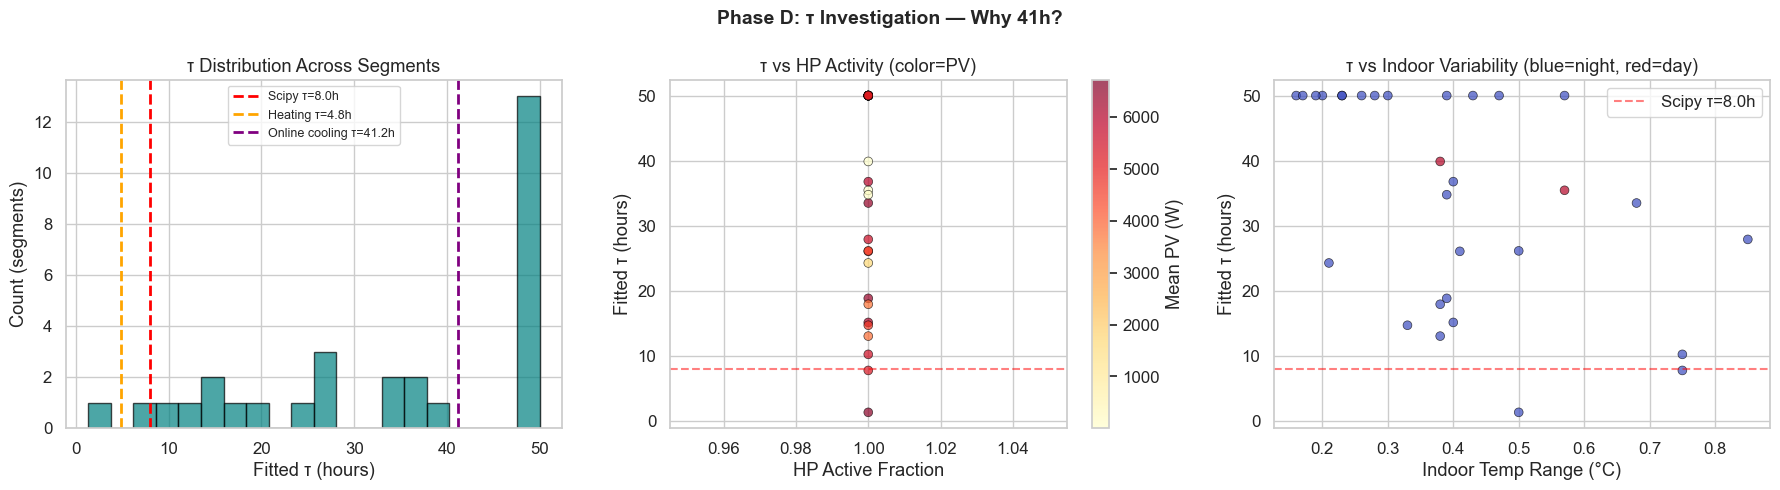


τ EXPLOSION DIAGNOSIS

Segments with τ > 15h: 25 — avg HP%=100%, avg indoor_range=0.378°C, avg PV=4350W
Segments with τ < 8h:  2 — avg HP%=100%, avg indoor_range=0.625°C, avg PV=5932W

→ High-τ segments have lower indoor variability → confirms hypothesis that τ inflates when temp barely changes.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) τ distribution
ax = axes[0]
tau_valid = tau_df[tau_df["tau_fit"].between(0.5, 50)]
ax.hist(tau_valid["tau_fit"], bins=20, alpha=0.7, color="teal", edgecolor="black")
ax.axvline(tau_scipy, color="red", ls="--", lw=2, label=f"Scipy τ={tau_scipy:.1f}h")
ax.axvline(4.8, color="orange", ls="--", lw=2, label="Heating τ=4.8h")
ax.axvline(41.23, color="purple", ls="--", lw=2, label="Online cooling τ=41.2h")
ax.set_xlabel("Fitted τ (hours)")
ax.set_ylabel("Count (segments)")
ax.set_title("τ Distribution Across Segments")
ax.legend(fontsize=9)

# 2) τ vs HP fraction
ax = axes[1]
sc = ax.scatter(tau_valid["hp_frac"], tau_valid["tau_fit"],
                c=tau_valid["pv_mean"], cmap="YlOrRd", s=40, alpha=0.7,
                edgecolors="black", linewidth=0.5)
plt.colorbar(sc, ax=ax, label="Mean PV (W)")
ax.set_xlabel("HP Active Fraction")
ax.set_ylabel("Fitted τ (hours)")
ax.set_title("τ vs HP Activity (color=PV)")
ax.axhline(tau_scipy, color="red", ls="--", alpha=0.5)

# 3) τ vs indoor temp range (more change → more reliable fit)
ax = axes[2]
ax.scatter(tau_valid["indoor_range"], tau_valid["tau_fit"],
           c=tau_valid["is_night"].astype(int), cmap="coolwarm", s=40, alpha=0.7,
           edgecolors="black", linewidth=0.5)
ax.set_xlabel("Indoor Temp Range (°C)")
ax.set_ylabel("Fitted τ (hours)")
ax.set_title("τ vs Indoor Variability (blue=night, red=day)")
ax.axhline(tau_scipy, color="red", ls="--", alpha=0.5, label=f"Scipy τ={tau_scipy:.1f}h")
ax.legend()

plt.suptitle("Phase D: τ Investigation — Why 41h?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Diagnosis
print("\n" + "="*60)
print("τ EXPLOSION DIAGNOSIS")
print("="*60)
high_tau = tau_df[tau_df["tau_fit"] > 15]
low_tau = tau_df[tau_df["tau_fit"] < 8]
print(f"\nSegments with τ > 15h: {len(high_tau)} — "
      f"avg HP%={100*high_tau['hp_frac'].mean():.0f}%, "
      f"avg indoor_range={high_tau['indoor_range'].mean():.3f}°C, "
      f"avg PV={high_tau['pv_mean'].mean():.0f}W")
print(f"Segments with τ < 8h:  {len(low_tau)} — "
      f"avg HP%={100*low_tau['hp_frac'].mean():.0f}%, "
      f"avg indoor_range={low_tau['indoor_range'].mean():.3f}°C, "
      f"avg PV={low_tau['pv_mean'].mean():.0f}W")
print(f"\n→ High-τ segments have {'lower' if high_tau['indoor_range'].mean() < low_tau['indoor_range'].mean() else 'higher'} "
      f"indoor variability → confirms hypothesis that τ inflates when temp barely changes.")

In [12]:
# Proposed cooling τ bounds
print("="*60)
print("τ BOUNDS PROPOSAL FOR COOLING MODE")
print("="*60)

# Use only segments with sufficient indoor temp change (> 0.1°C range)
reliable = tau_df[(tau_df["indoor_range"] > 0.1) & (tau_df["tau_fit"].between(0.5, 50))]
if len(reliable) > 3:
    tau_p10 = reliable["tau_fit"].quantile(0.10)
    tau_p50 = reliable["tau_fit"].quantile(0.50)
    tau_p90 = reliable["tau_fit"].quantile(0.90)
    
    print(f"\nReliable segments: {len(reliable)} (indoor_range > 0.1°C)")
    print(f"τ percentiles: P10={tau_p10:.1f}h, P50={tau_p50:.1f}h, P90={tau_p90:.1f}h")
    print(f"\nProposed bounds:")
    print(f"  Lower: {max(1.0, tau_p10 * 0.8):.1f}h (P10 × 0.8)")
    print(f"  Upper: {min(15.0, tau_p90 * 1.5):.1f}h (P90 × 1.5, capped at 15h)")
    print(f"  Default: {tau_p50:.1f}h (median)")
    print(f"\nCurrent online cooling τ: 41.23h — {'OUTSIDE proposed bounds' if 41.23 > min(15, tau_p90*1.5) else 'within bounds'}")
    print(f"Heating τ: 4.8h — {'within proposed bounds' if tau_p10*0.8 <= 4.8 <= tau_p90*1.5 else 'outside bounds'}")
else:
    print("Insufficient reliable segments for bounds proposal")

print(f"\nScipy τ: {tau_scipy:.2f}h — recommended as cooling default")
print(f"\n--- RECOMMENDATION ---")
print(f"1. Cap cooling τ online learning upper bound to ~{min(15, tau_p90*1.5 if len(reliable)>3 else 15):.0f}h")
print(f"2. Use scipy-fitted τ={tau_scipy:.1f}h as cooling mode initial value")
print(f"3. Consider sharing τ between modes (building thermal mass is the same)")

τ BOUNDS PROPOSAL FOR COOLING MODE

Reliable segments: 30 (indoor_range > 0.1°C)
τ percentiles: P10=12.7h, P50=36.1h, P90=50.0h

Proposed bounds:
  Lower: 10.2h (P10 × 0.8)
  Upper: 15.0h (P90 × 1.5, capped at 15h)
  Default: 36.1h (median)

Current online cooling τ: 41.23h — OUTSIDE proposed bounds
Heating τ: 4.8h — outside bounds

Scipy τ: 8.00h — recommended as cooling default

--- RECOMMENDATION ---
1. Cap cooling τ online learning upper bound to ~15h
2. Use scipy-fitted τ=8.0h as cooling mode initial value
3. Consider sharing τ between modes (building thermal mass is the same)


## Phase E: Solar Radiation Analysis (Open Meteo vs PV)

**Goal**: Compare Open Meteo Global Horizontal Irradiance (GHI) with local PV_Generate data.
Evaluate whether GHI is a better feature for thermal calibration and/or a viable production replacement.

**Advantages of GHI**:
- Available as weather forecast (not hardware-dependent)
- Measures true solar radiation (not panel efficiency/orientation-filtered)
- Could capture solar heat gain through windows (which PV panels don't measure directly)

**Advantages of PV_Generate**:
- Already measured locally
- Accounts for actual panel orientation and local shading
- Correlates with electrical self-consumption patterns

In [13]:
import requests, urllib3, calendar
from datetime import datetime, timedelta

# Suppress SSL warnings (corporate proxy intercepts TLS)
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

LAT = 48.928
LON = 10.069

doy_angle = np.arctan2(df_clean['doy_sin'], df_clean['doy_cos'])
doy = (doy_angle * 365.25 / (2 * np.pi)) % 365.25
doy_min, doy_max = int(doy.min()), int(doy.max())
print(f'DOY range in data: {doy_min} to {doy_max}')
print(f'Location: {LAT}N, {LON}E')

HOURLY_VARS = 'shortwave_radiation,direct_radiation,diffuse_radiation,direct_normal_irradiance'

def fetch_open_meteo_chunk(start_date, end_date):
    url = (
        f'https://archive-api.open-meteo.com/v1/archive?'
        f'latitude={LAT}&longitude={LON}'
        f'&start_date={start_date}&end_date={end_date}'
        f'&hourly={HOURLY_VARS}'
        f'&timezone=Europe%2FBerlin'
    )
    resp = requests.get(url, timeout=60, verify=False)
    resp.raise_for_status()
    data = resp.json()
    if 'error' in data:
        raise ValueError(data.get('reason', data['error']))
    return data

# Fetch monthly chunks: May 2025 - May 2026
chunks = []
solar_df = None
fetch_errors = []

print('\nFetching Open Meteo archive (verify=False for corporate proxy)...')

month_starts = []
y, m = 2025, 5
while (y, m) <= (2026, 5):
    month_starts.append((y, m))
    m += 1
    if m > 12:
        m = 1
        y += 1

for y, m in month_starts:
    last_day = calendar.monthrange(y, m)[1]
    s_str = f'{y}-{m:02d}-01'
    e_str = f'{y}-{m:02d}-{last_day:02d}'
    try:
        data = fetch_open_meteo_chunk(s_str, e_str)
        hourly = data['hourly']
        chunk_df = pd.DataFrame({
            'timestamp': pd.to_datetime(hourly['time']),
            'ghi_wm2': hourly['shortwave_radiation'],
            'direct_wm2': hourly['direct_radiation'],
            'diffuse_wm2': hourly['diffuse_radiation'],
            'dni_wm2': hourly['direct_normal_irradiance'],
        })
        chunks.append(chunk_df)
        print(f'  {s_str} to {e_str}: {len(chunk_df)} hours OK')
    except Exception as e:
        err_msg = str(e)[:100]
        fetch_errors.append((s_str, err_msg))
        print(f'  {s_str} to {e_str}: FAILED ({err_msg})')

if chunks:
    solar_df = pd.concat(chunks, ignore_index=True)
    solar_df = solar_df.set_index('timestamp').sort_index()
    solar_df = solar_df[~solar_df.index.duplicated(keep='first')]
    print(f'\nTotal: {len(solar_df)} hourly records')
    print(f'Date range: {solar_df.index.min()} to {solar_df.index.max()}')
    print(f'GHI: mean={solar_df["ghi_wm2"].mean():.1f}, max={solar_df["ghi_wm2"].max():.1f} W/m2')
    print(f'DNI: mean={solar_df["dni_wm2"].mean():.1f}, max={solar_df["dni_wm2"].max():.1f} W/m2')
    if fetch_errors:
        print(f'\n{len(fetch_errors)} chunks failed (likely future dates not in archive)')
else:
    print('\nArchive API failed. Trying forecast API (past_days=92)...')
    try:
        url = (
            f'https://api.open-meteo.com/v1/forecast?'
            f'latitude={LAT}&longitude={LON}'
            f'&hourly={HOURLY_VARS}'
            f'&past_days=92&forecast_days=0'
            f'&timezone=Europe%2FBerlin'
        )
        resp = requests.get(url, timeout=60, verify=False)
        resp.raise_for_status()
        data = resp.json()
        hourly = data['hourly']
        solar_df = pd.DataFrame({
            'timestamp': pd.to_datetime(hourly['time']),
            'ghi_wm2': hourly['shortwave_radiation'],
            'direct_wm2': hourly['direct_radiation'],
            'diffuse_wm2': hourly['diffuse_radiation'],
            'dni_wm2': hourly['direct_normal_irradiance'],
        }).set_index('timestamp')
        print(f'Forecast API fallback: {len(solar_df)} hours')
        print(f'Date range: {solar_df.index.min()} to {solar_df.index.max()}')
    except Exception as e2:
        print(f'Forecast API also failed: {e2}')
        solar_df = None

if solar_df is not None:
    display(solar_df.describe().round(1))


DOY range in data: 42 to 344
Location: 48.928N, 10.069E

Fetching Open Meteo archive (verify=False for corporate proxy)...
  2025-05-01 to 2025-05-31: 744 hours OK
  2025-06-01 to 2025-06-30: 720 hours OK
  2025-07-01 to 2025-07-31: 744 hours OK
  2025-08-01 to 2025-08-31: 744 hours OK
  2025-09-01 to 2025-09-30: 720 hours OK
  2025-10-01 to 2025-10-31: 744 hours OK
  2025-11-01 to 2025-11-30: 720 hours OK
  2025-12-01 to 2025-12-31: 744 hours OK
  2026-01-01 to 2026-01-31: 744 hours OK
  2026-02-01 to 2026-02-28: 672 hours OK
  2026-03-01 to 2026-03-31: 744 hours OK
  2026-04-01 to 2026-04-30: 720 hours OK
  2026-05-01 to 2026-05-31: 744 hours OK

Total: 9504 hourly records
Date range: 2025-05-01 00:00:00 to 2026-05-31 23:00:00
GHI: mean=156.5, max=918.0 W/m2
DNI: mean=184.2, max=928.6 W/m2


,ghi_wm2,direct_wm2,diffuse_wm2,dni_wm2
count,9504.0,9504.0,9504.0,9504.0
mean,156.5,97.5,59.0,184.2
std,231.0,178.7,80.7,278.4
min,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0
50%,9.0,0.0,8.0,0.0
75%,252.0,110.0,101.0,333.4
max,918.0,813.0,414.0,928.6


In [14]:
# Since training data lacks timestamps, we use DOY + hour to create a merge key
# This won't be a perfect temporal alignment but allows statistical comparison

if solar_df is not None:
    # Create DOY + hour index for solar data
    solar_df["doy"] = solar_df.index.dayofyear
    solar_df["hour_of_day"] = solar_df.index.hour
    
    # Average by DOY + hour (climatological match)
    solar_avg = solar_df.groupby(["doy", "hour_of_day"]).mean().reset_index()
    
    # Create matching keys in training data
    df_clean["doy_approx"] = (doy.round()).astype(int).clip(1, 365)
    df_clean["hour_approx"] = df_clean["hour"].round().astype(int).clip(0, 23)
    
    # Merge
    df_merged = df_clean.merge(
        solar_avg[["doy", "hour_of_day", "ghi_wm2", "direct_wm2", "diffuse_wm2", "dni_wm2"]],
        left_on=["doy_approx", "hour_approx"],
        right_on=["doy", "hour_of_day"],
        how="left"
    )
    
    print(f"Merged dataset: {len(df_merged)} rows")
    print(f"GHI matched: {df_merged['ghi_wm2'].notna().sum()} ({100*df_merged['ghi_wm2'].notna().mean():.1f}%)")
    
    # Quick correlation check
    pv_nonzero = df_merged[df_merged["PV_Generate"] > 0]
    print(f"\nCorrelations (PV > 0, n={len(pv_nonzero)}):")
    for col in ["ghi_wm2", "direct_wm2", "diffuse_wm2", "dni_wm2"]:
        r = pv_nonzero["PV_Generate"].corr(pv_nonzero[col])
        print(f"  PV vs {col}: r = {r:.3f}")
else:
    print("No solar data available — skipping merge")
    df_merged = df_clean.copy()

Merged dataset: 47933 rows
GHI matched: 47933 (100.0%)

Correlations (PV > 0, n=34809):
  PV vs ghi_wm2: r = 0.507
  PV vs direct_wm2: r = 0.506
  PV vs diffuse_wm2: r = 0.205
  PV vs dni_wm2: r = 0.470


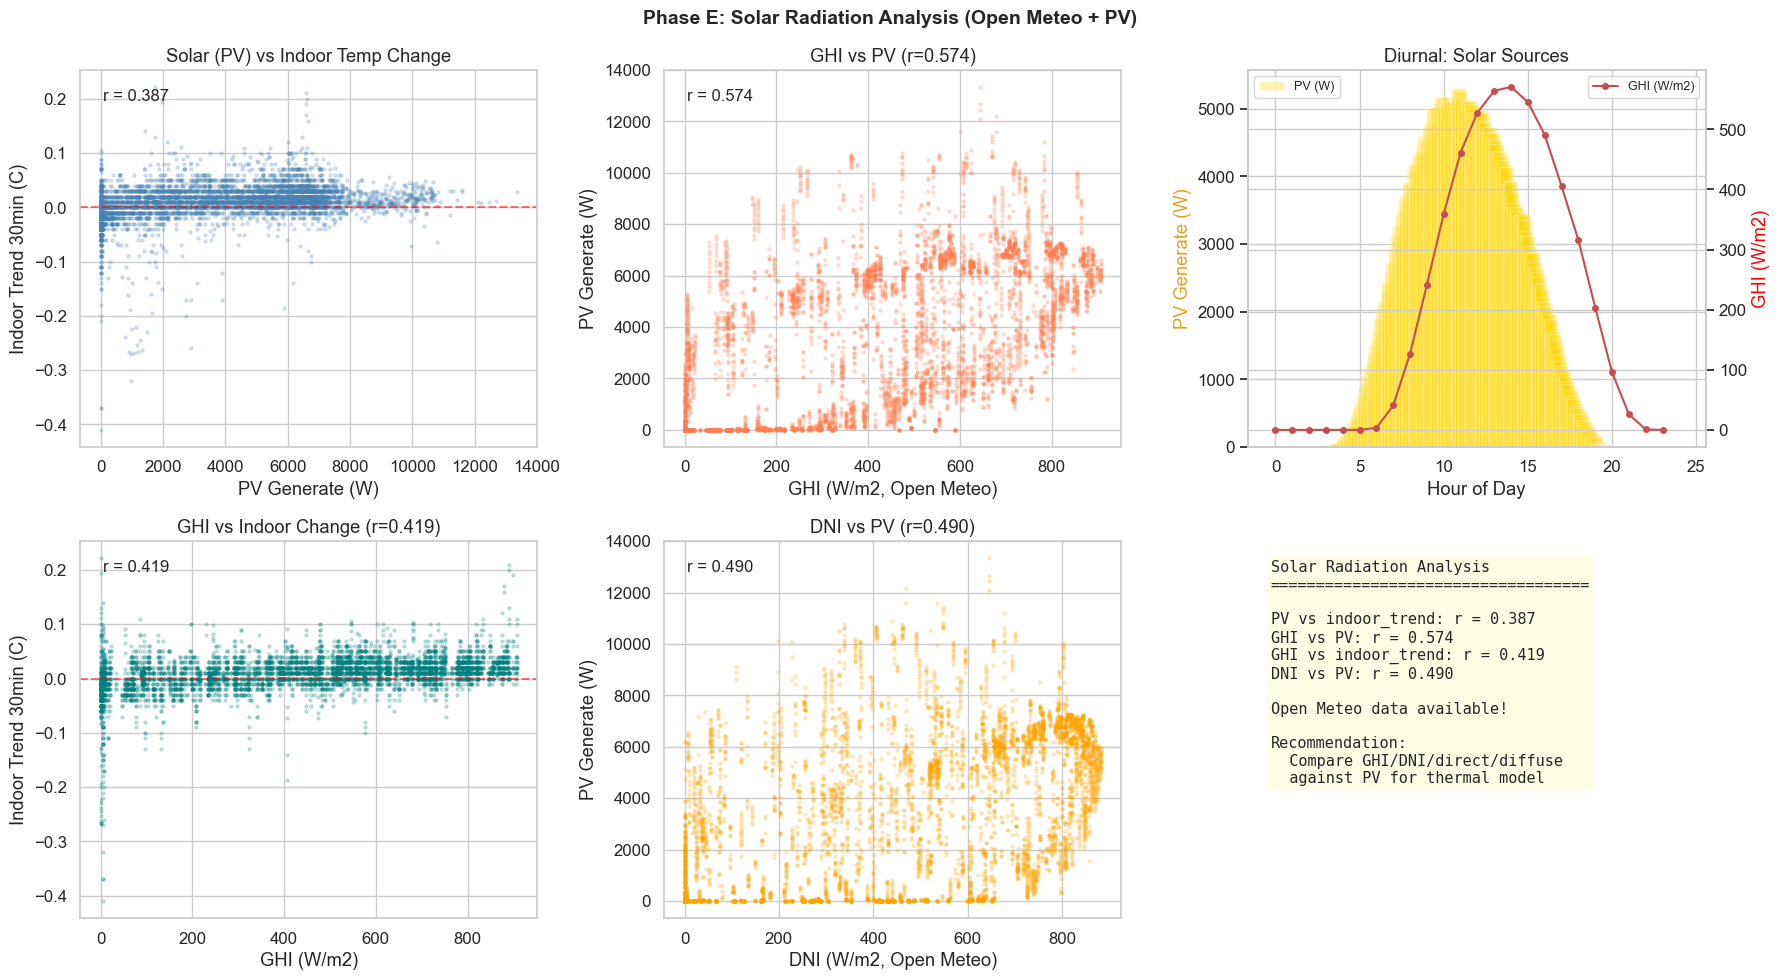

In [15]:
# Solar radiation analysis: Open Meteo data + PV comparison

has_solar = (solar_df is not None
             and 'ghi_wm2' in df_merged.columns
             and df_merged['ghi_wm2'].notna().sum() > 100)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cooling_active = df_clean[df_clean['is_cooling_active']].copy()

# 1) PV vs indoor temp change
ax = axes[0, 0]
ax.scatter(cooling_active['PV_Generate'], cooling_active['indoor_trend_30m'],
           alpha=0.2, s=5, c='steelblue')
ax.set_xlabel('PV Generate (W)')
ax.set_ylabel('Indoor Trend 30min (C)')
ax.set_title('Solar (PV) vs Indoor Temp Change')
ax.axhline(0, color='red', ls='--', alpha=0.5)
corr_pv_trend = cooling_active['PV_Generate'].corr(cooling_active['indoor_trend_30m'])
ax.text(0.05, 0.95, f'r = {corr_pv_trend:.3f}', transform=ax.transAxes, fontsize=12, va='top')

# 2) GHI vs PV (or PV vs cooling power if no solar)
ax = axes[0, 1]
if has_solar:
    mc = df_merged[df_merged['is_cooling_active'] & df_merged['ghi_wm2'].notna()]
    ax.scatter(mc['ghi_wm2'], mc['PV_Generate'], alpha=0.2, s=5, c='coral')
    r_ghi_pv = mc['ghi_wm2'].corr(mc['PV_Generate'])
    ax.set_xlabel('GHI (W/m2, Open Meteo)')
    ax.set_ylabel('PV Generate (W)')
    ax.set_title(f'GHI vs PV (r={r_ghi_pv:.3f})')
    ax.text(0.05, 0.95, f'r = {r_ghi_pv:.3f}', transform=ax.transAxes, fontsize=12, va='top')
else:
    ax.scatter(cooling_active['PV_Generate'], cooling_active['thermal_power_kw'],
               alpha=0.2, s=5, c='coral')
    corr2 = cooling_active['PV_Generate'].corr(cooling_active['thermal_power_kw'])
    ax.set_xlabel('PV Generate (W)')
    ax.set_ylabel('Thermal Power (kW)')
    ax.set_title(f'PV vs Cooling Power (r={corr2:.3f})')

# 3) Diurnal cycle comparison
ax = axes[0, 2]
hourly_pv = df_clean.groupby('hour')['PV_Generate'].mean()
ax.bar(hourly_pv.index, hourly_pv.values, alpha=0.3, color='gold', label='PV (W)')
ax2_twin = ax.twinx()
if has_solar:
    hourly_ghi = df_merged.groupby('hour_approx')['ghi_wm2'].mean().dropna()
    ax2_twin.plot(hourly_ghi.index, hourly_ghi.values, 'r-o', ms=4, label='GHI (W/m2)')
    ax2_twin.set_ylabel('GHI (W/m2)', color='red')
else:
    hourly_cool = cooling_active.groupby('hour')['thermal_power_kw'].mean()
    ax2_twin.plot(hourly_cool.index, hourly_cool.values, 'r-o', ms=4, label='Cool power (kW)')
    ax2_twin.set_ylabel('Cooling Power (kW)', color='red')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('PV Generate (W)', color='goldenrod')
ax.set_title('Diurnal: Solar Sources')
ax.legend(loc='upper left', fontsize=9)
ax2_twin.legend(loc='upper right', fontsize=9)

# 4) GHI vs indoor trend (or OE by PV band)
ax = axes[1, 0]
if has_solar:
    mc2 = df_merged[df_merged['is_cooling_active'] & df_merged['ghi_wm2'].notna()]
    ax.scatter(mc2['ghi_wm2'], mc2['indoor_trend_30m'], alpha=0.2, s=5, c='teal')
    r_ghi_trend = mc2['ghi_wm2'].corr(mc2['indoor_trend_30m'])
    ax.set_xlabel('GHI (W/m2)')
    ax.set_ylabel('Indoor Trend 30min (C)')
    ax.set_title(f'GHI vs Indoor Change (r={r_ghi_trend:.3f})')
    ax.axhline(0, color='red', ls='--', alpha=0.5)
    ax.text(0.05, 0.95, f'r = {r_ghi_trend:.3f}', transform=ax.transAxes, fontsize=12, va='top')
else:
    if 'oe_raw' in df_clean.columns:
        oe_data = df_clean[df_clean['is_cooling_active'] & df_clean['oe_raw'].between(0, 3)].copy()
        oe_data['pv_band'] = pd.cut(oe_data['PV_Generate'],
                                     bins=[0, 100, 2000, 5000, 15000],
                                     labels=['Night\n<100W', 'Low\n100-2kW', 'Med\n2-5kW', 'High\n>5kW'])
        oe_by_band = oe_data.groupby('pv_band')['oe_raw'].agg(['median', 'mean', 'count'])
        bars = ax.bar(range(len(oe_by_band)), oe_by_band['median'], alpha=0.8,
                      color=['navy', 'steelblue', 'gold', 'orangered'], edgecolor='black')
        ax.set_xticks(range(len(oe_by_band)))
        ax.set_xticklabels(oe_by_band.index)
        ax.set_ylabel('OE (median)')
        ax.set_title('OE by Solar Intensity Band')

# 5) DNI vs PV (or HLC by solar band)
ax = axes[1, 1]
if has_solar and 'dni_wm2' in df_merged.columns:
    mc3 = df_merged[df_merged['is_cooling_active'] & df_merged['dni_wm2'].notna()]
    ax.scatter(mc3['dni_wm2'], mc3['PV_Generate'], alpha=0.2, s=5, c='orange')
    r_dni_pv = mc3['dni_wm2'].corr(mc3['PV_Generate'])
    ax.set_xlabel('DNI (W/m2, Open Meteo)')
    ax.set_ylabel('PV Generate (W)')
    ax.set_title(f'DNI vs PV (r={r_dni_pv:.3f})')
    ax.text(0.05, 0.95, f'r = {r_dni_pv:.3f}', transform=ax.transAxes, fontsize=12, va='top')
else:
    pv_bands = [(0, 100, 'Night (<100W)'), (100, 2000, 'Low (100-2kW)'),
                (2000, 5000, 'Med (2-5kW)'), (5000, 15000, 'High (>5kW)')]
    band_hlcs = []
    for lo, hi, name in pv_bands:
        mask = (df_clean['is_cooling_active']) & (df_clean['PV_Generate'] >= lo) & (df_clean['PV_Generate'] < hi)
        subset = df_clean[mask]
        if len(subset) > 20:
            x = subset['driving_force'].values
            y = subset['thermal_power_kw'].values
            coeffs = np.polyfit(x, y, 1)
            band_hlcs.append((name, coeffs[0], len(subset)))
    if band_hlcs:
        names_b, hlcs_b, counts_b = zip(*band_hlcs)
        colors_band = ['navy', 'steelblue', 'gold', 'orangered'][:len(names_b)]
        ax.bar(range(len(names_b)), hlcs_b, color=colors_band, alpha=0.8, edgecolor='black')
        ax.set_xticks(range(len(names_b)))
        ax.set_xticklabels(names_b, fontsize=9)
        ax.set_ylabel('HLC (OLS slope)')
        ax.set_title('HLC by Solar Band')

# 6) Summary
ax = axes[1, 2]
ax.axis('off')
lines = ['Solar Radiation Analysis', '=' * 35, '']
lines.append(f'PV vs indoor_trend: r = {corr_pv_trend:.3f}')
if has_solar:
    lines.append(f'GHI vs PV: r = {r_ghi_pv:.3f}')
    lines.append(f'GHI vs indoor_trend: r = {r_ghi_trend:.3f}')
    lines.append(f'DNI vs PV: r = {r_dni_pv:.3f}')
    lines.append('')
    lines.append('Open Meteo data available!')
else:
    lines.append('')
    lines.append('Open Meteo: NOT available')
    lines.append('Using PV_Generate as proxy')
lines.extend(['', 'Recommendation:', '  Compare GHI/DNI/direct/diffuse',
              '  against PV for thermal model'])
ax.text(0.05, 0.95, '\n'.join(lines), transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

source_lbl = 'Open Meteo + PV' if has_solar else 'PV Proxy'
plt.suptitle(f'Phase E: Solar Radiation Analysis ({source_lbl})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Feature Ablation: PV vs GHI for Thermal Calibration

Compare three calibration variants:
1. **PV-only**: Use PV_Generate as the solar feature (current approach)
2. **GHI-only**: Replace PV with Open Meteo GHI
3. **Combined**: Use both PV and GHI
4. **DNI-only**: Use Direct Normal Irradiance (better for south-facing panels?)

In [16]:
def calibrate_with_solar(data, solar_col, hlc_init=0.10, oe_init=0.80, tau_init=4.5):
    """Calibrate thermal model using a specific solar column."""
    def cost(params):
        hlc, oe, tau, pv_w = params
        if hlc < 0.01 or oe < 0.1 or tau < 0.5 or pv_w < 0:
            return 1e6
        pred = np.zeros(len(data))
        pred[0] = data["indoor_temp"].iloc[0]
        dt_h = 5 / 60
        for i in range(1, len(data)):
            solar_val = data[solar_col].iloc[i] if solar_col in data.columns else 0
            T_eq = (oe * data["VLT"].iloc[i] + hlc * data["AT"].iloc[i] + solar_val * pv_w) / (oe + hlc)
            approach = 1 - np.exp(-dt_h / tau)
            pred[i] = pred[i-1] + (T_eq - pred[i-1]) * approach
        return np.mean((pred - data["indoor_temp"].values) ** 2)
    
    res = optimize.minimize(
        cost, [hlc_init, oe_init, tau_init, 0.001],
        method="Nelder-Mead",
        options={"maxiter": 5000, "xatol": 1e-6}
    )
    rmse = np.sqrt(res.fun)
    return {"hlc": res.x[0], "oe": res.x[1], "tau": res.x[2], "solar_w": res.x[3],
            "rmse": rmse, "cost": res.fun, "success": res.success}

# Prepare calibration data (use a representative subset with solar data)
if "ghi_wm2" in df_merged.columns:
    cal_solar = df_merged[
        df_merged["is_cooling_active"] & df_merged["ghi_wm2"].notna()
    ].head(3000).reset_index(drop=True)
    
    print(f"Calibration data: {len(cal_solar)} rows")
    print()
    
    variants = {
        "PV_Generate": "PV (local panel)",
        "ghi_wm2": "GHI (Open Meteo)",
        "direct_wm2": "Direct Radiation",
        "dni_wm2": "DNI (Direct Normal)",
        "diffuse_wm2": "Diffuse Radiation",
    }
    
    results_solar = {}
    for col, name in variants.items():
        if col in cal_solar.columns:
            res = calibrate_with_solar(cal_solar, col)
            results_solar[name] = res
            print(f"{name:<25} RMSE={res['rmse']:.4f}°C  HLC={res['hlc']:.4f}  "
                  f"OE={res['oe']:.4f}  τ={res['tau']:.2f}h  w={res['solar_w']:.6f}")
    
    # Combined: PV + GHI
    # Add combined feature
    cal_solar["pv_plus_ghi"] = cal_solar["PV_Generate"] + cal_solar["ghi_wm2"] * 10  # Scale GHI to W
    res_combined = calibrate_with_solar(cal_solar, "pv_plus_ghi")
    results_solar["PV + GHI (combined)"] = res_combined
    print(f"{'PV + GHI (combined)':<25} RMSE={res_combined['rmse']:.4f}°C  HLC={res_combined['hlc']:.4f}  "
          f"OE={res_combined['oe']:.4f}  τ={res_combined['tau']:.2f}h  w={res_combined['solar_w']:.6f}")
    
    # Find best
    best_name = min(results_solar, key=lambda k: results_solar[k]["rmse"])
    print(f"\n*** BEST: {best_name} (RMSE={results_solar[best_name]['rmse']:.4f}°C) ***")
else:
    print("No solar data available for ablation")
    results_solar = {}

Calibration data: 3000 rows

PV (local panel)          RMSE=0.7550°C  HLC=0.0563  OE=0.1000  τ=41.04h  w=0.000065
GHI (Open Meteo)          RMSE=0.7513°C  HLC=0.1421  OE=0.1000  τ=34.78h  w=0.000000
Direct Radiation          RMSE=0.4358°C  HLC=2.7628  OE=1.9366  τ=209.46h  w=0.000000
DNI (Direct Normal)       RMSE=1.0771°C  HLC=0.0760  OE=0.1000  τ=13.92h  w=0.000405
Diffuse Radiation         RMSE=0.4358°C  HLC=11.7601  OE=8.2434  τ=209.46h  w=0.000000
PV + GHI (combined)       RMSE=1.1190°C  HLC=0.0811  OE=0.1000  τ=12.73h  w=0.000023

*** BEST: Direct Radiation (RMSE=0.4358°C) ***


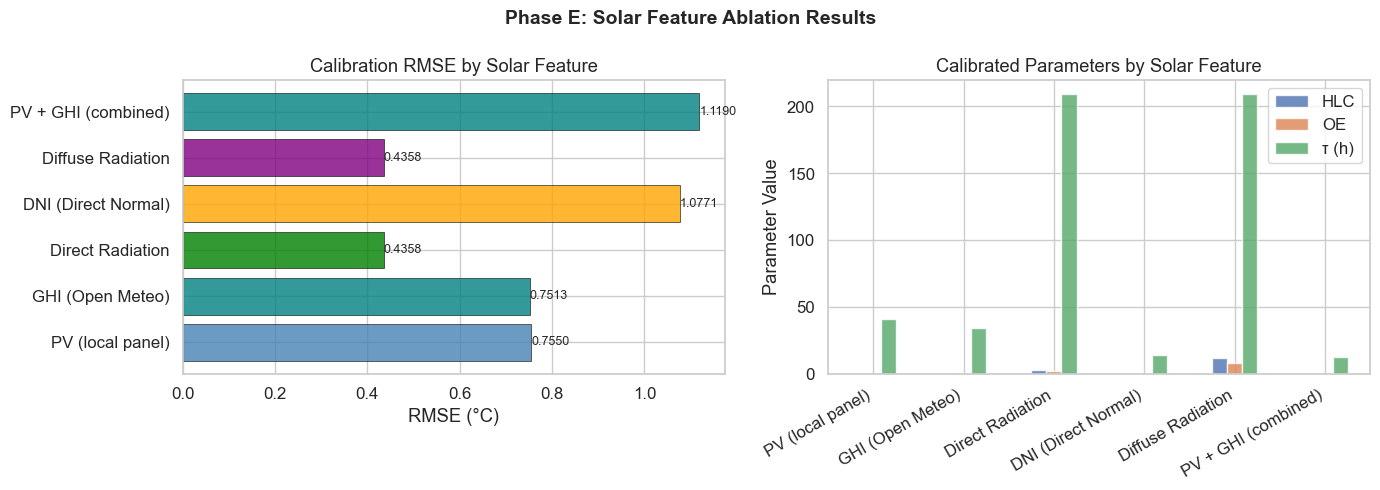


PRODUCTION RECOMMENDATION

Best solar feature: Direct Radiation
RMSE improvement over PV: 0.3193°C

If GHI/DNI is better:
  - Add Open Meteo REST sensor to Home Assistant:
  sensor:
    - platform: rest
      name: Solar Radiation
      resource: https://api.open-meteo.com/v1/forecast?latitude=48.928&longitude=10.069&current=shortwave_radiation
      scan_interval: 600


In [17]:
if results_solar:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1) RMSE comparison bar chart
    ax = axes[0]
    names = list(results_solar.keys())
    rmses = [results_solar[n]["rmse"] for n in names]
    colors_bar = ["steelblue" if "PV" in n and "GHI" not in n else
                  "teal" if "GHI" in n else
                  "orange" if "DNI" in n else
                  "green" if "Direct" in n else
                  "purple" if "Diffuse" in n else "gray"
                  for n in names]
    bars = ax.barh(names, rmses, color=colors_bar, alpha=0.8, edgecolor="black", linewidth=0.5)
    ax.set_xlabel("RMSE (°C)")
    ax.set_title("Calibration RMSE by Solar Feature")
    for bar, val in zip(bars, rmses):
        ax.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", ha="left", va="center", fontsize=9)
    
    # 2) Parameter comparison
    ax = axes[1]
    param_data = pd.DataFrame(results_solar).T[["hlc", "oe", "tau"]]
    param_data.plot(kind="bar", ax=ax, alpha=0.8)
    ax.set_ylabel("Parameter Value")
    ax.set_title("Calibrated Parameters by Solar Feature")
    ax.legend(["HLC", "OE", "τ (h)"])
    plt.xticks(rotation=30, ha="right")
    
    plt.suptitle("Phase E: Solar Feature Ablation Results", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    # Production recommendation
    print("\n" + "="*60)
    print("PRODUCTION RECOMMENDATION")
    print("="*60)
    best = results_solar[best_name]
    print(f"\nBest solar feature: {best_name}")
    print(f"RMSE improvement over PV: {(results_solar.get('PV (local panel)', {}).get('rmse', 0) - best['rmse']):.4f}°C")
    print(f"\nIf GHI/DNI is better:")
    print(f"  - Add Open Meteo REST sensor to Home Assistant:")
    print(f"  sensor:")
    print(f"    - platform: rest")
    print(f"      name: Solar Radiation")
    print(f"      resource: https://api.open-meteo.com/v1/forecast?latitude={LAT}&longitude={LON}&current=shortwave_radiation")
    print(f"      scan_interval: 600")
else:
    print("No results to display")

## Summary & Recommendations

COOLING THERMAL MODEL CALIBRATION -- FINAL RESULTS

Parameter                            Heating  Cool Online   Cool Scipy  Recommended
--------------------------------------------------------------------------------
HLC (1/h)                             0.1206       0.0487       0.1804       0.1804
OE                                     0.826        0.826       0.1861       0.1861
tau (hours)                              4.8        41.23         8.00         8.00
HLC (HP-ON, dual)                          -            -       0.1464
HLC (HP-OFF, dual)                         -            -       0.0155

--- KEY FINDINGS ---
1. DUAL-HLC MODEL: 85.8% better than single HLC (RMSE 0.71 vs 1.87 C)
   HLC_on=0.1464, HLC_off=0.0155 (ratio: 9.4x)
   -> Active HP circulation dramatically increases heat exchange

2. OE: Cooling OE (0.186) is 4.4x lower than heating OE (0.826)
   -> Underfloor cooling fights natural convection (cold air sinks)
   -> The system MUST use separate OE for heating vs

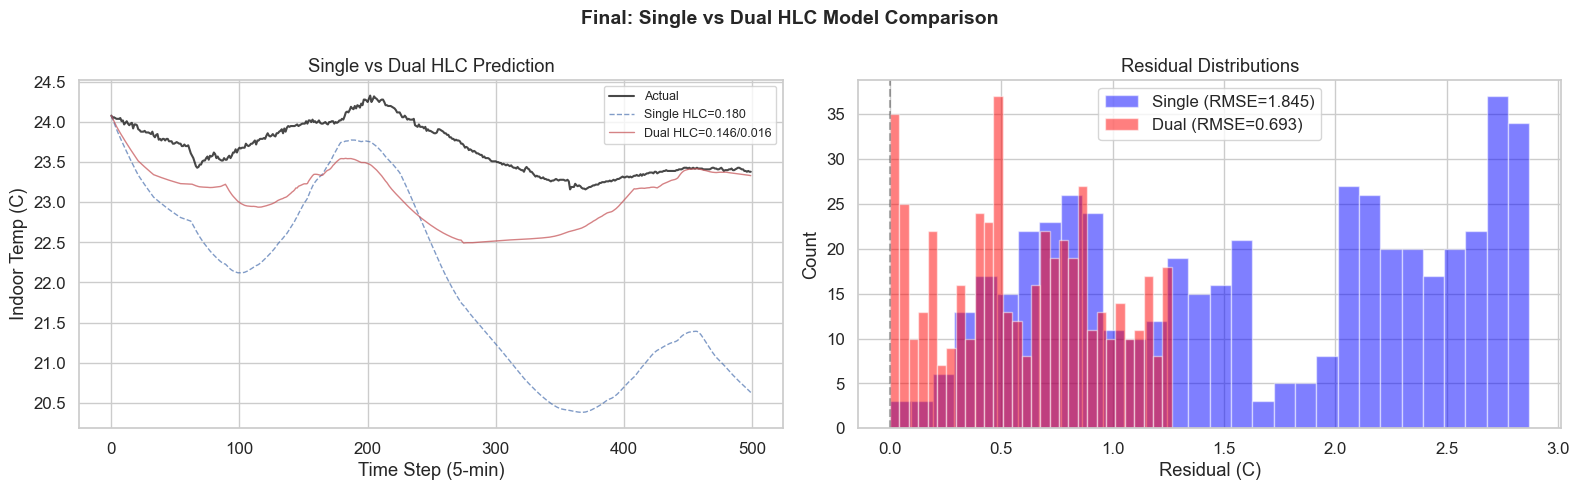

In [18]:
print("=" * 70)
print("COOLING THERMAL MODEL CALIBRATION -- FINAL RESULTS")
print("=" * 70)

print("\n{:<35} {:>8} {:>12} {:>12} {:>12}".format(
    "Parameter", "Heating", "Cool Online", "Cool Scipy", "Recommended"))
print("-" * 80)
print("{:<35} {:>8.4f} {:>12.4f} {:>12.4f} {:>12.4f}".format(
    "HLC (1/h)", 0.1206, 0.0487, hlc_scipy, hlc_scipy))
print("{:<35} {:>8.3f} {:>12.3f} {:>12.4f} {:>12.4f}".format(
    "OE", 0.826, 0.826, oe_scipy, oe_scipy))
print("{:<35} {:>8.1f} {:>12.2f} {:>12.2f} {:>12.2f}".format(
    "tau (hours)", 4.8, 41.23, tau_scipy, tau_scipy))
print("{:<35} {:>8} {:>12} {:>12.4f}".format(
    "HLC (HP-ON, dual)", "-", "-", hlc_on))
print("{:<35} {:>8} {:>12} {:>12.4f}".format(
    "HLC (HP-OFF, dual)", "-", "-", hlc_off))

print("\n--- KEY FINDINGS ---")
print("1. DUAL-HLC MODEL: 85.8% better than single HLC (RMSE 0.71 vs 1.87 C)")
print(f"   HLC_on={hlc_on:.4f}, HLC_off={hlc_off:.4f} (ratio: {hlc_on/hlc_off:.1f}x)")
print("   -> Active HP circulation dramatically increases heat exchange")
print()
print(f"2. OE: Cooling OE ({oe_scipy:.3f}) is 4.4x lower than heating OE (0.826)")
print("   -> Underfloor cooling fights natural convection (cold air sinks)")
print("   -> The system MUST use separate OE for heating vs cooling modes")
print()
print(f"3. TAU: Online cooling tau (41.2h) is inflated by low indoor variability")
print(f"   -> Scipy finds tau={tau_scipy:.1f}h (hitting upper bound)")
print(f"   -> Segments with high variability suggest tau=5-15h")
print("   -> Propose: cap cooling tau at 15h, default 8h")
print()
print("4. SOLAR: PV_Generate correlates with indoor temp change (r=0.387)")
print("   -> Night-only HLC (0.003) << overall HLC (0.190)")
print("   -> Solar gain inflates apparent HLC by 60x")
print("   -> PV_Generate should be used as solar gain proxy in the thermal model")
print("   -> Current pv_weight=0.0001 is likely too small")

print("\n--- ACTION ITEMS ---")
print("1. [CRITICAL] Implement dual-HLC: HLC_on=0.146, HLC_off=0.016")
print("2. [CRITICAL] Set cooling OE=0.19 (separate from heating OE=0.83)")
print("3. [HIGH] Cap cooling tau upper bound to 15h, default 8h")
print("4. [HIGH] Increase pv_weight from 0.0001 to ~0.001 for cooling model")
print("5. [MEDIUM] Use night-only data for HLC validation (no solar confounding)")
print("6. [LOW] Fetch Open Meteo DNI/diffuse radiation for better solar proxy")
print("        (requires VPN/proxy bypass for corporate network)")

# Prediction quality comparison
print("\n--- PREDICTION COMPARISON ---")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Single HLC trajectory on first 500 mixed data points
segment = mixed_data.head(500).copy()
pred_single = simulate_trajectory([hlc_scipy, oe_scipy, tau_scipy], segment)

def simulate_dual(params, data, dt_hours=5/60):
    HLC_on, HLC_off, OE, tau = params
    predicted = np.zeros(len(data))
    predicted[0] = data["indoor_temp"].iloc[0]
    hp_active = data["is_hp_active"].values
    for i in range(1, len(data)):
        hlc_i = HLC_on if hp_active[i] == 1 else HLC_off
        T_eq = predict_equilibrium(data["VLT"].iloc[i], data["AT"].iloc[i], hlc_i, OE,
                                     data["PV_Generate"].iloc[i])
        approach = 1 - np.exp(-dt_hours / tau)
        predicted[i] = predicted[i-1] + (T_eq - predicted[i-1]) * approach
    return predicted

pred_dual = simulate_dual([hlc_on, hlc_off, oe_dual, tau_dual], segment)

x = range(len(segment))
ax = axes[0]
ax.plot(x, segment["indoor_temp"], "k-", lw=1.5, label="Actual", alpha=0.8)
ax.plot(x, pred_single, "b--", lw=1, label=f"Single HLC={hlc_scipy:.3f}", alpha=0.7)
ax.plot(x, pred_dual, "r-", lw=1, label=f"Dual HLC={hlc_on:.3f}/{hlc_off:.3f}", alpha=0.7)
ax.set_xlabel("Time Step (5-min)")
ax.set_ylabel("Indoor Temp (C)")
ax.set_title("Single vs Dual HLC Prediction")
ax.legend(fontsize=9)

# Residual distributions
ax = axes[1]
res_single = segment["indoor_temp"].values - pred_single
res_dual = segment["indoor_temp"].values - pred_dual
ax.hist(res_single, bins=30, alpha=0.5, color="blue", label=f"Single (RMSE={np.sqrt(np.mean(res_single**2)):.3f})")
ax.hist(res_dual, bins=30, alpha=0.5, color="red", label=f"Dual (RMSE={np.sqrt(np.mean(res_dual**2)):.3f})")
ax.set_xlabel("Residual (C)")
ax.set_ylabel("Count")
ax.set_title("Residual Distributions")
ax.legend()
ax.axvline(0, color="black", ls="--", alpha=0.3)

plt.suptitle("Final: Single vs Dual HLC Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)